<a href="https://colab.research.google.com/github/Kshama13/diabetes-FL-/blob/main/MP_modelv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Privacy-Preserving Diabetes and Heart Disease Prediction using Federated Learning and WCO

## Data Preprocessing

This notebook implements the data preprocessing phase of the proposed Federated Learning and Weighted Conglomeration Optimization (WCO) framework.

### Objectives

- Load the Diabetes Prediction Dataset
- Explore and understand the dataset
- Perform Exploratory Data Analysis (EDA)
- Clean the dataset
- Transform and preprocess the features
- Balance the dataset using SMOTE
- Split the data into training and testing sets
- Create simulated client datasets for Federated Learning

The processed data will be used in the next stage for local model training and federated aggregation.

## Step 1: Import Required Libraries

This section imports all the Python libraries required for:

- Data manipulation
- Data visualization
- Feature engineering
- Data preprocessing
- Feature selection
- Data balancing using SMOTE
- Train-test splitting
- Federated client simulation

In [161]:
# ================================
# Install required package (Run once in Google Colab)
# ================================

!pip install -q imbalanced-learn

In [162]:
# ================================
# Import Libraries
# ================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import mutual_info_classif

from imblearn.over_sampling import SMOTE

## Step 2: Load the Dataset

The proposed model uses the Diabetes Prediction Dataset.

This dataset contains demographic information, medical history, laboratory measurements, and the diabetes status of patients.

The dataset will be used for preprocessing before Federated Learning.

In [163]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("DataSet.csv")

In [164]:
# Display first five records

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [165]:
# Display last five records

df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


## Step 3: Dataset Overview

Understanding the dataset is important before applying any preprocessing techniques.

In this section, we examine:

- Number of rows
- Number of columns
- Feature names
- Data types
- Memory usage

In [166]:
# Dataset Shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 100000
Number of Columns : 9


In [167]:
# Display column names

print(df.columns.tolist())

['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [168]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [169]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [170]:
# Display categorical feature summary

df.describe(include='object')

,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [171]:
# Check data types

df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


# Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset before preprocessing.

The objectives of this section are to:

- Check missing values
- Check duplicate records
- Analyze target class distribution
- Explore numerical and categorical features
- Detect outliers
- Identify feature relationships using correlation analysis

These observations guide the preprocessing steps that follow.

In [172]:
# Display the first 10 rows

df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [173]:
# Display the dimensions of the dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 9


## Missing Value Analysis

Missing values reduce model performance.

Before preprocessing, we check whether any feature contains null values.

In [174]:
# Count missing values

missing_values = df.isnull().sum()

missing_values

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [175]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
gender,0.0
age,0.0
hypertension,0.0
heart_disease,0.0
smoking_history,0.0
bmi,0.0
HbA1c_level,0.0
blood_glucose_level,0.0
diabetes,0.0


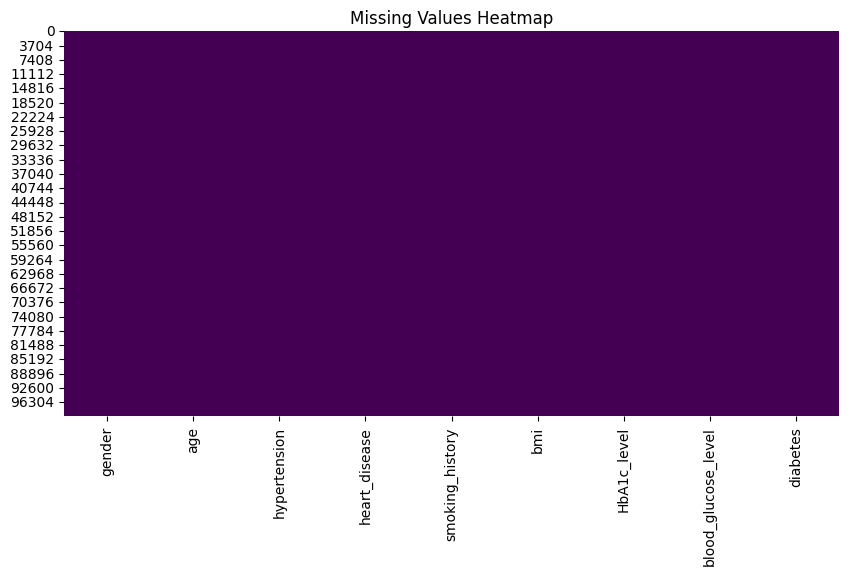

In [176]:
# Visualize missing values

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

## Duplicate Record Analysis

Duplicate records can bias the machine learning model.

We first count duplicate rows and later remove them during preprocessing if necessary.

In [177]:
# Count duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 3854


In [178]:
# Display duplicate rows (if any)

df[df.duplicated()].head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2756,Male,80.0,0,0,No Info,27.32,6.6,159,0
3272,Female,80.0,0,0,No Info,27.32,3.5,80,0
3418,Female,19.0,0,0,No Info,27.32,6.5,100,0
3939,Female,78.0,1,0,former,27.32,3.5,130,0
3960,Male,47.0,0,0,No Info,27.32,6.0,200,0


## Class Distribution

The target variable is **diabetes**.

Understanding whether the classes are balanced helps determine if resampling techniques such as SMOTE are required.

In [179]:
# Class distribution

df['diabetes'].value_counts()

,count
diabetes,
0,91500
1,8500


In [180]:
# Percentage distribution

(df['diabetes'].value_counts(normalize=True)*100).round(2)

,proportion
diabetes,
0,91.5
1,8.5


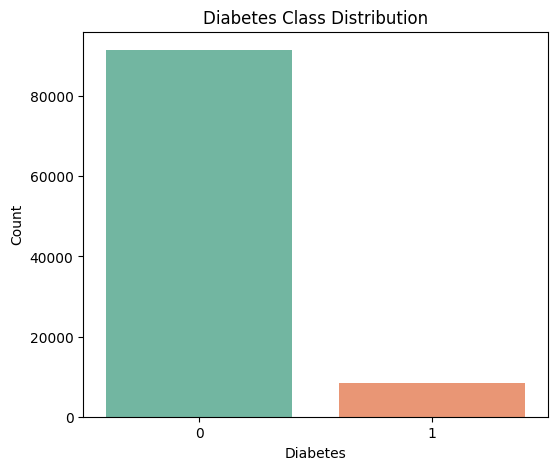

In [181]:
# Count plot of target variable

plt.figure(figsize=(6,5))

sns.countplot(
    x='diabetes',
    data=df,
    palette='Set2'
)

plt.title("Diabetes Class Distribution")

plt.xlabel("Diabetes")

plt.ylabel("Count")

plt.show()

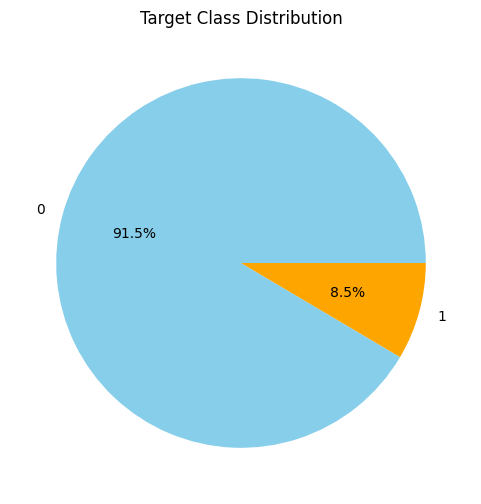

In [182]:
# Pie chart of target variable

plt.figure(figsize=(6,6))

df['diabetes'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange']
)

plt.ylabel("")

plt.title("Target Class Distribution")

plt.show()

## Distribution of Numerical Features

Histograms help us understand the distribution of continuous variables such as:

- Age
- BMI
- HbA1c Level
- Blood Glucose Level

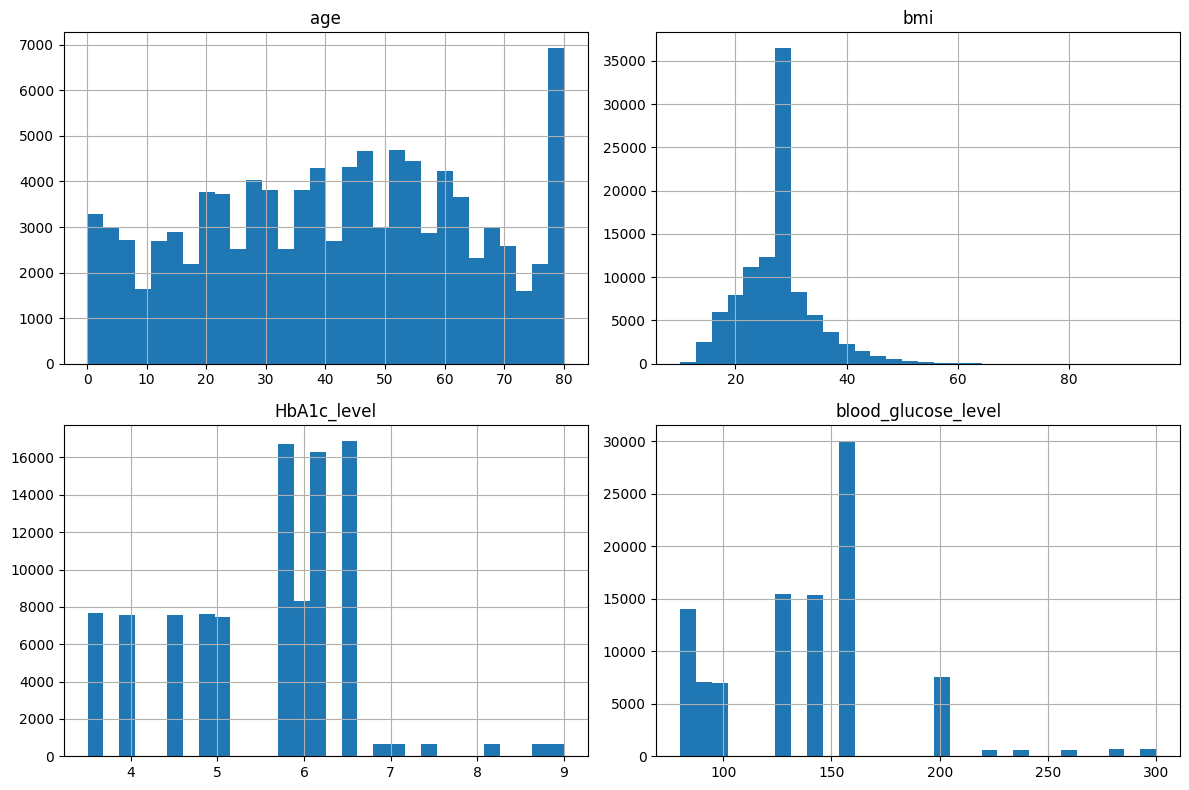

In [183]:
# Histograms

numerical_features = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

df[numerical_features].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()

plt.show()

## Boxplots

Boxplots help identify outliers present in numerical variables.

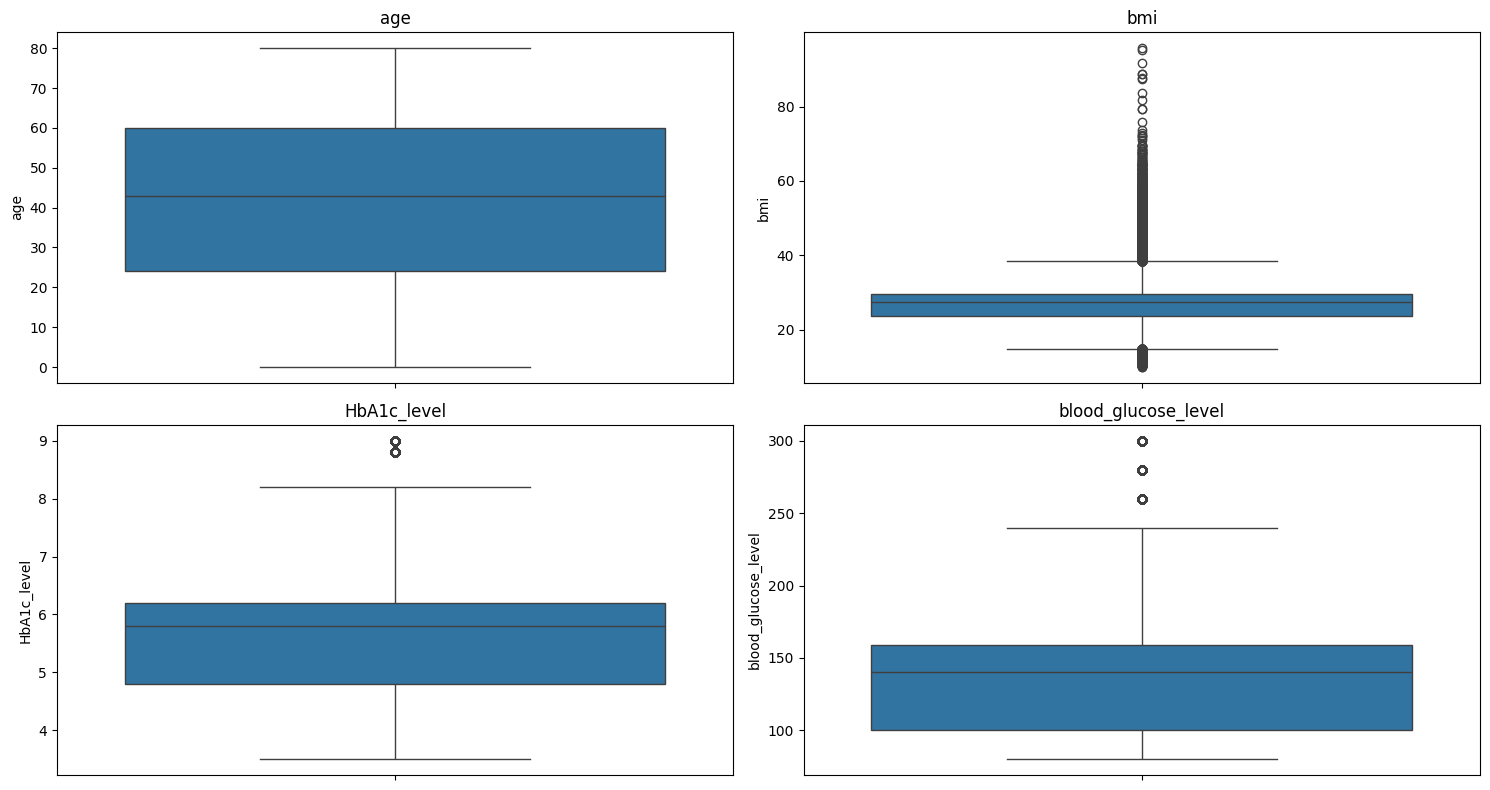

In [184]:
plt.figure(figsize=(15,8))

for i,col in enumerate(numerical_features):

    plt.subplot(2,2,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

## Categorical Feature Distribution

This section visualizes categorical variables.

Examples include:

- Gender
- Hypertension
- Heart Disease
- Smoking History

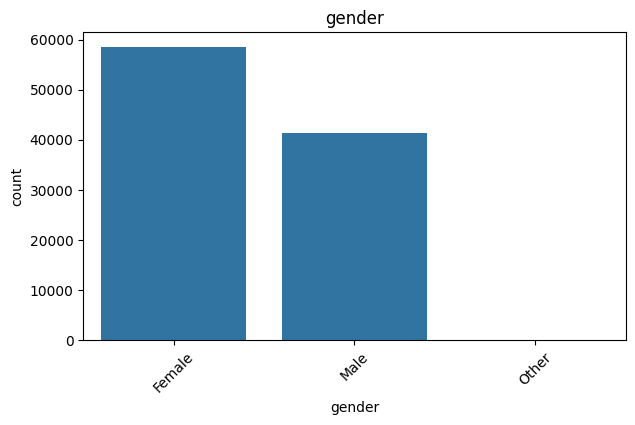

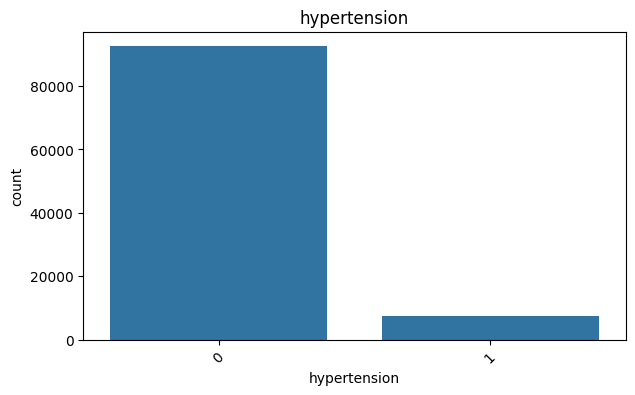

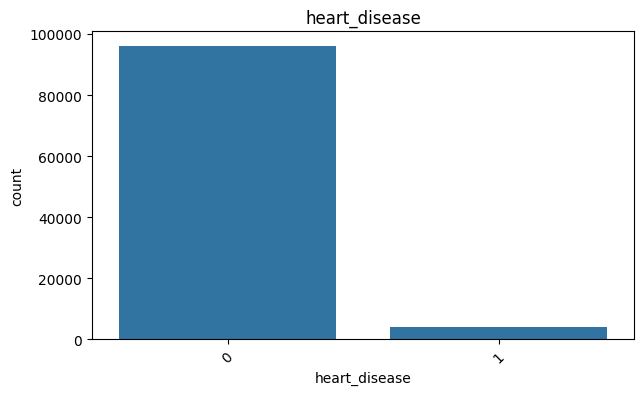

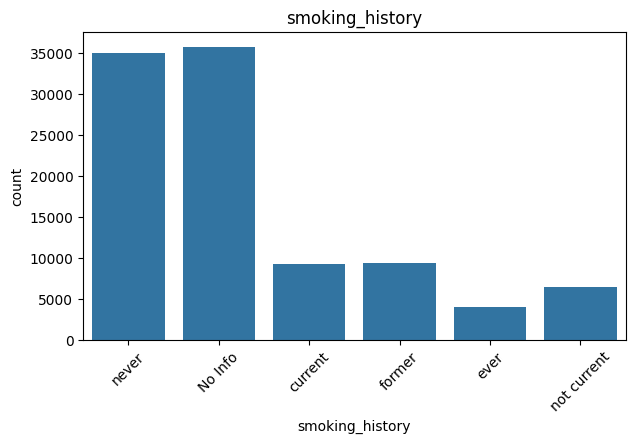

In [185]:
categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'smoking_history'
]

for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        x=feature,
        data=df
    )

    plt.title(feature)

    plt.xticks(rotation=45)

    plt.show()

## Correlation Analysis

Correlation measures the strength of relationships between numerical variables.

A heatmap provides an easy way to visualize these relationships.

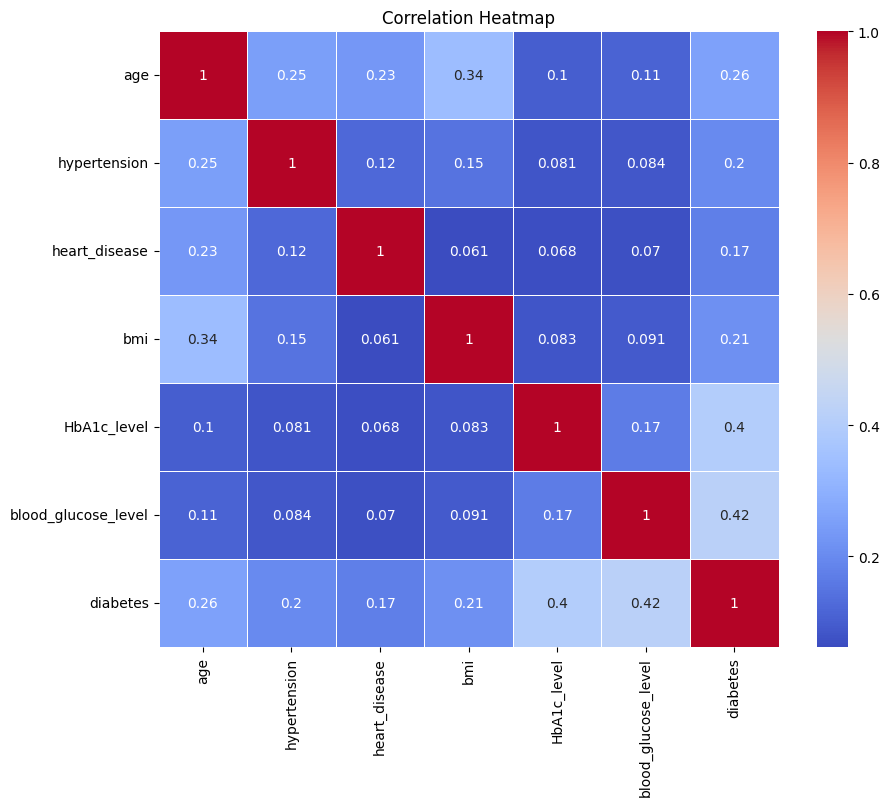

In [186]:
# Select only numerical columns

numeric_df = df.select_dtypes(include=['int64','float64'])

correlation = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [189]:
# Display unique values in each categorical column

for col in categorical_features:

    print(f"\n{col}")

    print(df[col].value_counts())


gender
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

hypertension
hypertension
0    92515
1     7485
Name: count, dtype: int64

heart_disease
heart_disease
0    96058
1     3942
Name: count, dtype: int64

smoking_history
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


# Observations from Exploratory Data Analysis

From the exploratory analysis, we identified:

- Dataset dimensions and feature types.
- Missing value status.
- Duplicate records.
- Distribution of numerical variables.
- Distribution of categorical variables.
- Class imbalance in the target variable.
- Correlation among numerical features.
- Potential outliers in continuous variables.

These insights will guide the preprocessing stage, where the data will be cleaned, encoded, normalized, balanced using SMOTE, and prepared for Federated Learning.

# Step 5: Data Preprocessing

After understanding the dataset through Exploratory Data Analysis (EDA), the next step is preprocessing.

The preprocessing stage includes:

- Removing duplicate records
- Handling missing values
- Encoding categorical variables
- Selecting important features
- Scaling numerical features
- Balancing the dataset using SMOTE

These steps improve the quality of the dataset before training machine learning models.

## Remove Duplicate Records

Duplicate records may introduce bias during model training.

They are removed to improve the quality of the dataset.

In [190]:
# Number of rows before removing duplicates

print("Rows before removing duplicates :", len(df))

Rows before removing duplicates : 100000


In [191]:
# Remove duplicate records

df = df.drop_duplicates()

In [192]:
# Number of rows after removing duplicates

print("Rows after removing duplicates :", len(df))

Rows after removing duplicates : 96146


In [193]:
# Verify duplicate removal

print("Remaining duplicate rows :", df.duplicated().sum())

Remaining duplicate rows : 0


## Handle Missing Values

The dataset is checked once again for missing values.

If any missing values are present, they are handled appropriately.

In [194]:
# Missing values in each column

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [195]:
# Fill missing values (if any)

for column in df.columns:

    if df[column].dtype == 'object':

        df[column].fillna(df[column].mode()[0], inplace=True)

    else:

        df[column].fillna(df[column].median(), inplace=True)

In [196]:
# Verify missing values

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


## Encode Categorical Variables

Machine learning algorithms require numerical inputs.

Categorical features are converted into numerical values using Label Encoding.

In [197]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['gender', 'smoking_history'], dtype='object')

In [198]:
# Apply Label Encoding

encoder = LabelEncoder()

for column in categorical_columns:

    df[column] = encoder.fit_transform(df[column])

In [199]:
# Display first few rows after encoding

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


## Separate Features and Target Variable

The dataset is divided into:

- Feature matrix (X)
- Target variable (y)

In [200]:
# Features

X = df.drop("diabetes", axis=1)

# Target

y = df["diabetes"]
print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (96146, 8)
Target Shape : (96146,)


## Feature Selection using Mutual Information

Feature selection improves model performance by selecting the most informative features.

Mutual Information measures the dependency between each feature and the target variable.

In [201]:
# Calculate Mutual Information Scores

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)
# Create DataFrame

mi_df = pd.DataFrame({

    "Feature": X.columns,

    "MI Score": mi_scores

})

mi_df

,Feature,MI Score
0,gender,0.010138
1,age,0.043281
2,hypertension,0.013212
3,heart_disease,0.010494
4,smoking_history,0.016350
5,bmi,0.024566
6,HbA1c_level,0.134220
7,blood_glucose_level,0.116699


In [202]:
# Sort Features

mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
)

mi_df

,Feature,MI Score
6,HbA1c_level,0.134220
7,blood_glucose_level,0.116699
1,age,0.043281
5,bmi,0.024566
4,smoking_history,0.016350
2,hypertension,0.013212
3,heart_disease,0.010494
0,gender,0.010138


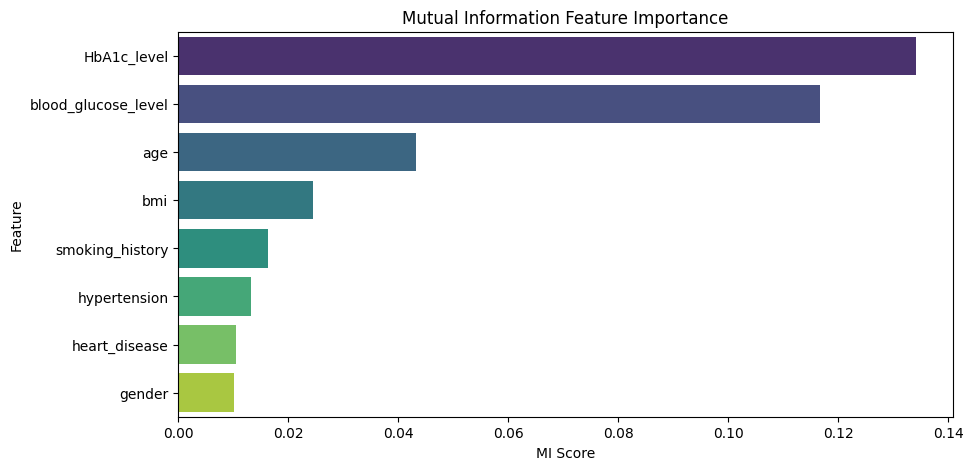

In [203]:
# Feature Importance Plot

plt.figure(figsize=(10,5))

sns.barplot(

    x="MI Score",

    y="Feature",

    data=mi_df,

    palette="viridis"

)

plt.title("Mutual Information Feature Importance")

plt.show()

,Feature,MI Score
6,HbA1c_level,0.134220
7,blood_glucose_level,0.116699
1,age,0.043281
5,bmi,0.024566
4,smoking_history,0.016350
2,hypertension,0.013212
3,heart_disease,0.010494
0,gender,0.010138


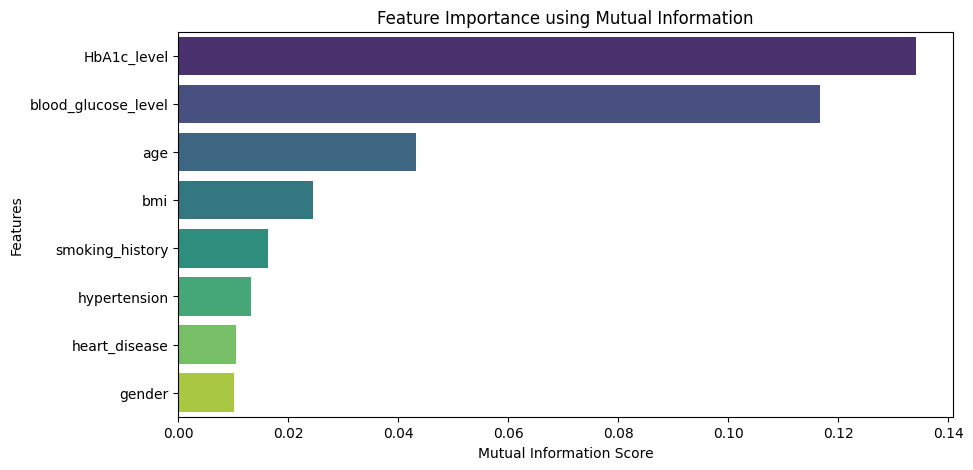


Selected Features:
['HbA1c_level', 'blood_glucose_level', 'age', 'bmi', 'smoking_history', 'hypertension', 'heart_disease', 'gender']

Scaled Dataset


,HbA1c_level,blood_glucose_level,age,bmi,smoking_history,hypertension,heart_disease,gender
0,0.994563,0.043554,1.700840,-0.314947,0.940896,-0.290050,4.848534,-0.843459
1,0.994563,-1.423096,0.543372,-0.000216,-1.186816,-0.290050,-0.206248,-0.843459
2,0.155970,0.483549,-0.614096,-0.000216,0.940896,-0.290050,-0.206248,1.183769
3,-0.496269,0.410216,-0.257952,-0.572051,-0.654888,-0.290050,-0.206248,-0.843459
4,-0.682623,0.410216,1.522768,-1.061141,-0.654888,3.447677,4.848534,1.183769



Statistical Summary After Scaling


,count,mean,std,min,25%,50%,75%,max
HbA1c_level,96146.0,2.397396e-16,1.000005,-1.893923,-0.682623,0.249147,0.621855,3.230810
blood_glucose_level,96146.0,-8.129272e-17,1.000005,-1.423096,-0.934213,0.043554,0.507993,3.954620
age,96146.0,3.400992e-16,1.000005,-1.857038,-0.792168,0.053674,0.765962,1.700840
bmi,96146.0,-3.800804e-16,1.000005,-2.557961,-0.579439,-0.000216,0.375097,10.102212
smoking_history,96146.0,8.897858e-17,1.000005,-1.186816,-1.186816,0.408968,0.940896,1.472825
hypertension,96146.0,-1.551952e-17,1.000005,-0.290050,-0.290050,-0.290050,-0.290050,3.447677
heart_disease,96146.0,-6.178247e-17,1.000005,-0.206248,-0.206248,-0.206248,-0.206248,4.848534
gender,96146.0,-1.140130e-16,1.000005,-0.843459,-0.843459,-0.843459,1.183769,3.210998


In [204]:
# -----------------------------
# Feature Selection
# -----------------------------

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create Feature Importance DataFrame
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

# Sort Features
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

# Display Scores
display(mi_df)

# Plot Feature Importance
plt.figure(figsize=(10,5))
sns.barplot(
    data=mi_df,
    x="MI Score",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance using Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.show()

# Keep all selected features
selected_features = mi_df["Feature"].tolist()

X = X[selected_features]

print("\nSelected Features:")
print(selected_features)

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaled Dataset")
display(X_scaled.head())

print("\nStatistical Summary After Scaling")
display(X_scaled.describe().T)

## Handling Class Imbalance using SMOTE

The dataset is imbalanced because diabetic cases are fewer than non-diabetic cases.

SMOTE generates synthetic samples for the minority class, resulting in a balanced dataset for model training.

Class Distribution Before SMOTE
diabetes
0    87664
1     8482
Name: count, dtype: int64

Class Distribution After SMOTE
diabetes
0    87664
1    87664
Name: count, dtype: int64


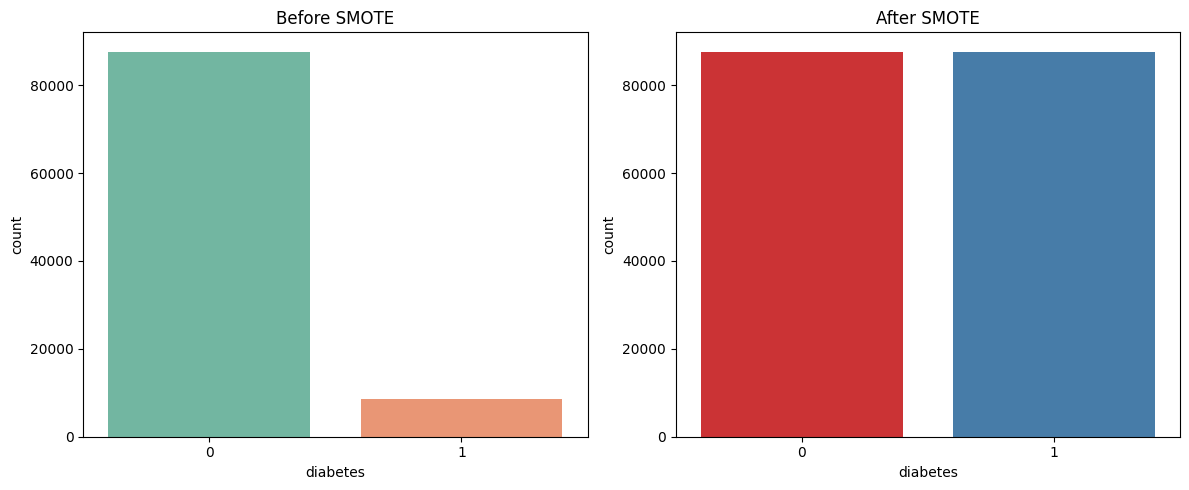

In [205]:
# -----------------------------
# Before SMOTE
# -----------------------------

print("Class Distribution Before SMOTE")
print(y.value_counts())
# Apply SMOTE

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

# After SMOTE

print("\nClass Distribution After SMOTE")
print(y_balanced.value_counts())

# Visual Comparison

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=y,
    ax=axes[0],
    palette="Set2"
)

axes[0].set_title("Before SMOTE")

sns.countplot(
    x=y_balanced,
    ax=axes[1],
    palette="Set1"
)

axes[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

## Observations

After preprocessing:

- Duplicate records were removed.
- Missing values were handled.
- Categorical variables were encoded.
- Important features were selected using Mutual Information.
- Numerical features were standardized using StandardScaler.
- The dataset was balanced using SMOTE.

The processed dataset is now ready for train-test splitting and Federated Learning simulation.

# Step 6: Train-Test Split

After preprocessing and balancing the dataset, the data is divided into training and testing sets.

- Training Set (80%) is used for local model training at each client.
- Testing Set (20%) is reserved for evaluating the global federated model.

A fixed random state ensures reproducibility.

In [206]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=42,
    stratify=y_balanced
)

print("="*50)
print("Train-Test Split Summary")
print("="*50)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Train-Test Split Summary
Training Features : (140262, 8)
Testing Features  : (35066, 8)
Training Labels   : (140262,)
Testing Labels    : (35066,)

Training Class Distribution
diabetes
1    70131
0    70131
Name: count, dtype: int64

Testing Class Distribution
diabetes
0    17533
1    17533
Name: count, dtype: int64


# Step 7: Federated Learning Client Simulation

To simulate Federated Learning, the training dataset is divided into four independent clients.

Each client represents a healthcare institution or hospital that trains its local model without sharing raw patient data.

Only the locally learned model parameters are exchanged with the central server during federated aggregation.

In [207]:
# ==========================================
# Simulate Four Federated Clients
# ==========================================

import numpy as np

# Split training data into four equal parts
X_clients = np.array_split(X_train, 4)
y_clients = np.array_split(y_train, 4)

client_data = {}

print("="*60)
print("Federated Client Summary")
print("="*60)

for i in range(4):

    client_name = f"Client_{i+1}"

    client_data[client_name] = {
        "X_train": X_clients[i],
        "y_train": y_clients[i]
    }

    print(f"\n{client_name}")

    print(f"Samples : {len(X_clients[i])}")

    print("Class Distribution")

    print(y_clients[i].value_counts())

print("\nTotal Clients Created :", len(client_data))

Federated Client Summary

Client_1
Samples : 35066
Class Distribution
diabetes
1    17574
0    17492
Name: count, dtype: int64

Client_2
Samples : 35066
Class Distribution
diabetes
0    17664
1    17402
Name: count, dtype: int64

Client_3
Samples : 35065
Class Distribution
diabetes
1    17639
0    17426
Name: count, dtype: int64

Client_4
Samples : 35065
Class Distribution
diabetes
0    17549
1    17516
Name: count, dtype: int64

Total Clients Created : 4


# Step 8: Verify and Save Client Datasets

Each client's data is stored separately.

These datasets will later be used for:

- Local model training
- Local evaluation
- Federated parameter aggregation using FedAvg + WCO

The test dataset remains common and is never split among clients.

In [208]:
# ==========================================
# Save Client Datasets
# ==========================================

import os

os.makedirs("Federated_Clients", exist_ok=True)

for client_name, data in client_data.items():

    client_df = data["X_train"].copy()

    client_df["diabetes"] = data["y_train"].values

    file_path = f"Federated_Clients/{client_name}.csv"

    client_df.to_csv(file_path, index=False)

print("Client datasets saved successfully!")

# Save common testing dataset

test_df = X_test.copy()
test_df["diabetes"] = y_test.values

test_df.to_csv("Federated_Clients/Test_Data.csv", index=False)

print("Testing dataset saved successfully!")

Client datasets saved successfully!
Testing dataset saved successfully!


In [209]:
# ==========================================
# Final Verification
# ==========================================

print("="*60)
print("Final Dataset Summary")
print("="*60)

print(f"Original Dataset Size      : {len(df)}")
print(f"Balanced Dataset Size      : {len(X_balanced)}")
print(f"Training Samples           : {len(X_train)}")
print(f"Testing Samples            : {len(X_test)}")
print(f"Federated Clients Created  : {len(client_data)}")

print("\nClient Dataset Sizes")

for client_name, data in client_data.items():

    print(f"{client_name} : {len(data['X_train'])} samples")

print("\nData preprocessing completed successfully.")
print("Dataset is ready for Federated Learning simulation.")

Final Dataset Summary
Original Dataset Size      : 96146
Balanced Dataset Size      : 175328
Training Samples           : 140262
Testing Samples            : 35066
Federated Clients Created  : 4

Client Dataset Sizes
Client_1 : 35066 samples
Client_2 : 35066 samples
Client_3 : 35065 samples
Client_4 : 35065 samples

Data preprocessing completed successfully.
Dataset is ready for Federated Learning simulation.


# Summary of Data Preparation

The data preparation pipeline has been successfully completed.

The following steps were performed:

- Dataset loading and exploration
- Exploratory Data Analysis (EDA)
- Duplicate removal
- Missing value handling
- Label encoding of categorical variables
- Feature selection using Mutual Information
- Feature standardization using StandardScaler
- Class balancing using SMOTE
- Train-test split
- Simulation of four federated clients
- Saving client datasets for local model training

The processed data is now ready for the Federated Learning stage, where each client will independently train a local model before model aggregation using Federated Averaging (FedAvg) enhanced with Weighted Conglomeration Optimization (WCO).

Model Development - Random Forest

In [210]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [211]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [212]:
y_pred = rf.predict(X_test)

In [213]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9776991958022015
Precision: 0.9771549022959038
Recall   : 0.9782695488507386
F1 Score : 0.9777119078834863

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17533
           1       0.98      0.98      0.98     17533

    accuracy                           0.98     35066
   macro avg       0.98      0.98      0.98     35066
weighted avg       0.98      0.98      0.98     35066



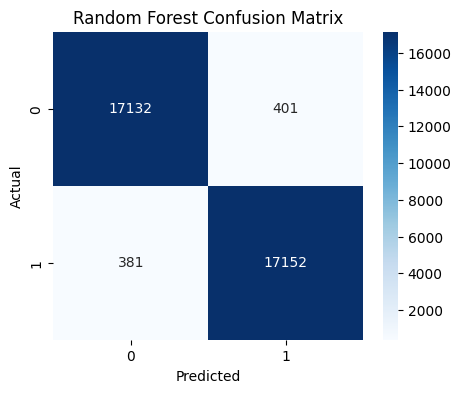

In [214]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [215]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9980260540642707


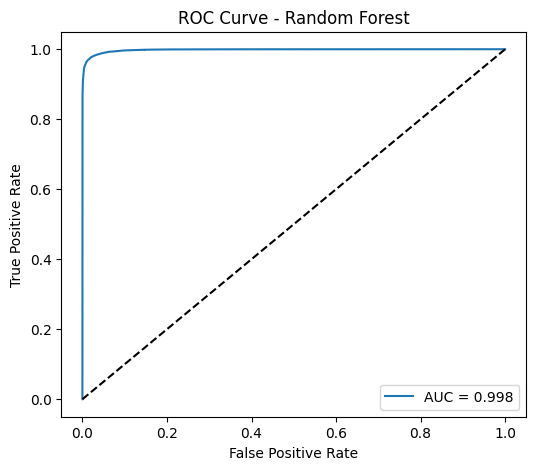

In [216]:
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc
}
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

XGBoost

In [217]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

Accuracy : 0.9719956653168311
Precision: 0.9904
Recall   : 0.9532310500199623
F1 Score : 0.9714601255521972
ROC-AUC  : 0.9967654202841766

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     17533
           1       0.99      0.95      0.97     17533

    accuracy                           0.97     35066
   macro avg       0.97      0.97      0.97     35066
weighted avg       0.97      0.97      0.97     35066



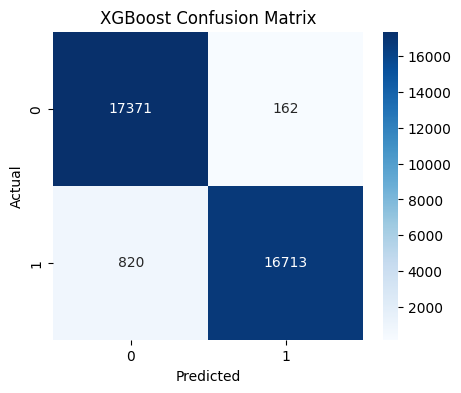

In [218]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

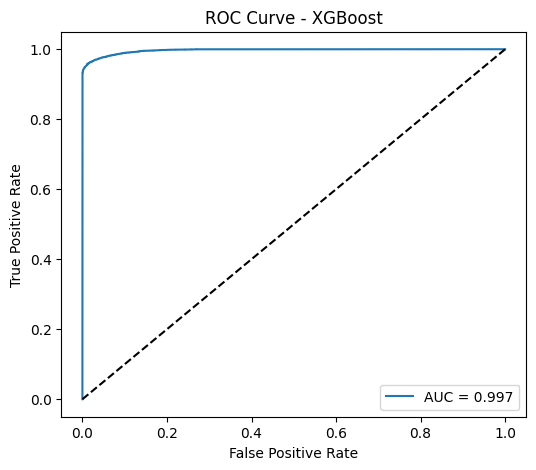

In [219]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [220]:
results["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

AdaBoost

In [221]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
y_prob = ada.predict_proba(X_test)[:, 1]

In [222]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9206353732960703
Precision: 0.9084967320261438
Recall   : 0.9354930702104602
F1 Score : 0.9217972855256132
ROC-AUC  : 0.9825101626402721

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     17533
           1       0.91      0.94      0.92     17533

    accuracy                           0.92     35066
   macro avg       0.92      0.92      0.92     35066
weighted avg       0.92      0.92      0.92     35066



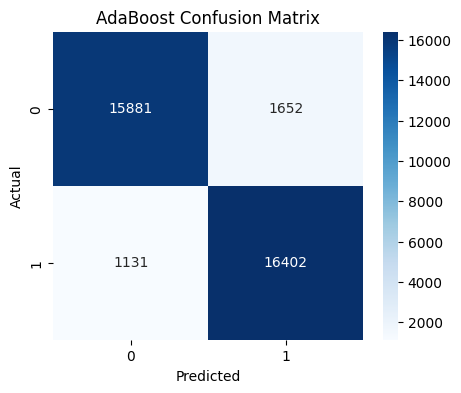

In [223]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

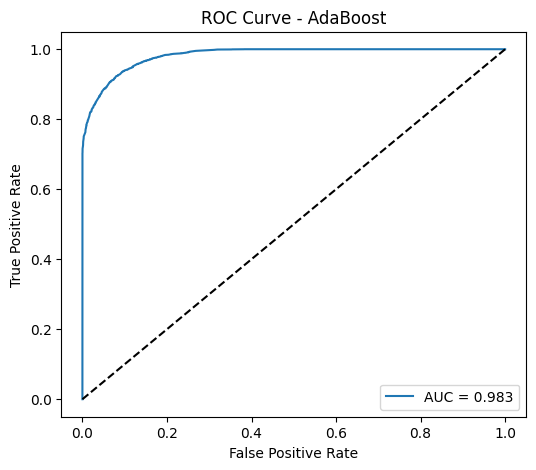

In [224]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()

plt.show()

In [225]:
results["AdaBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

Gradient Boosting

In [226]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

Accuracy : 0.9570238977927337
Precision: 0.9674483724186209
Recall   : 0.9458734956938345
F1 Score : 0.9565392934390772
ROC-AUC  : 0.9938957715310577

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17533
           1       0.97      0.95      0.96     17533

    accuracy                           0.96     35066
   macro avg       0.96      0.96      0.96     35066
weighted avg       0.96      0.96      0.96     35066



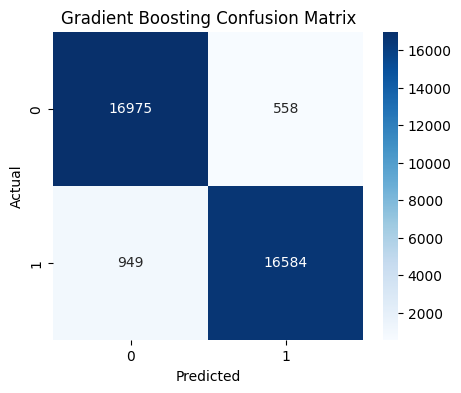

In [227]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

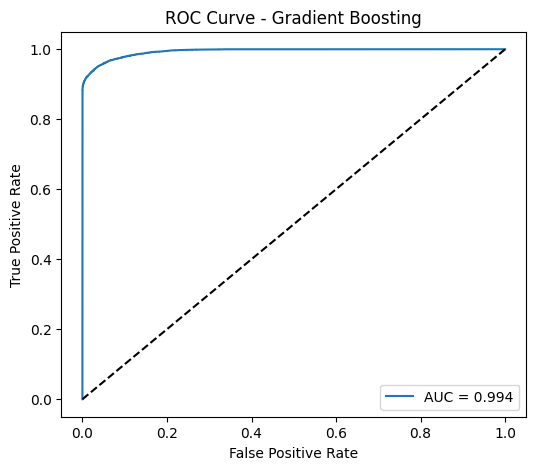

In [228]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()

In [229]:
results["Gradient Boosting"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

In [230]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)[:, 1]
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9205783379912166
Precision: 0.9223851529384809
Recall   : 0.9184395140592027
F1 Score : 0.9204081049412706
ROC-AUC  : 0.982062634094408

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     17533
           1       0.92      0.92      0.92     17533

    accuracy                           0.92     35066
   macro avg       0.92      0.92      0.92     35066
weighted avg       0.92      0.92      0.92     35066



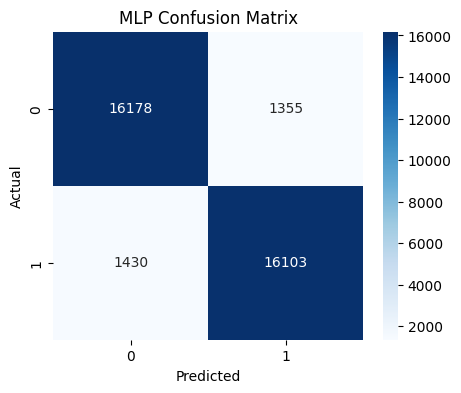

In [231]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

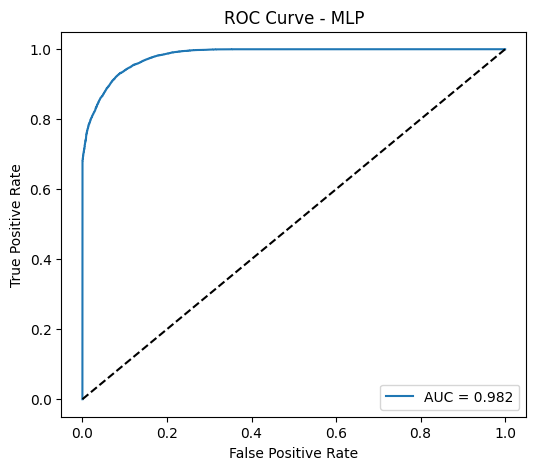

In [232]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()

plt.show()
results["MLP"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

comparison table

In [233]:
results_df = pd.DataFrame(results).T

display(results_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.977699,0.977155,0.978270,0.977712,0.998026
XGBoost,0.971996,0.990400,0.953231,0.971460,0.996765
AdaBoost,0.920635,0.908497,0.935493,0.921797,0.982510
Gradient Boosting,0.957024,0.967448,0.945873,0.956539,0.993896
MLP,0.920578,0.922385,0.918440,0.920408,0.982063


In [234]:
results_df.to_csv("model_summary.csv")

Federated Learning - Client Data Split

In [235]:
from sklearn.model_selection import train_test_split

# Client 1 = 25%
X_client1, X_remaining, y_client1, y_remaining = train_test_split(
    X_train,
    y_train,
    test_size=0.75,
    random_state=42,
    stratify=y_train
)

# Client 2 = 25%
X_client2, X_remaining, y_client2, y_remaining = train_test_split(
    X_remaining,
    y_remaining,
    test_size=2/3,
    random_state=42,
    stratify=y_remaining
)

# Split remaining equally
X_client3, X_client4, y_client3, y_client4 = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.5,
    random_state=42,
    stratify=y_remaining
)

print("Client 1:", X_client1.shape)
print("Client 2:", X_client2.shape)
print("Client 3:", X_client3.shape)
print("Client 4:", X_client4.shape)

Client 1: (35065, 8)
Client 2: (35065, 8)
Client 3: (35066, 8)
Client 4: (35066, 8)


In [236]:
for i, y in enumerate([y_client1, y_client2, y_client3, y_client4], start=1):
    print(f"\nClient {i}")
    print(y.value_counts())


Client 1
diabetes
1    17533
0    17532
Name: count, dtype: int64

Client 2
diabetes
0    17533
1    17532
Name: count, dtype: int64

Client 3
diabetes
1    17533
0    17533
Name: count, dtype: int64

Client 4
diabetes
0    17533
1    17533
Name: count, dtype: int64


In [237]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [238]:
from sklearn.ensemble import RandomForestClassifier

rf_results = []

clients = [
    ("Client_1", X_client1, y_client1),
    ("Client_2", X_client2, y_client2),
    ("Client_3", X_client3, y_client3),
    ("Client_4", X_client4, y_client4),
]

for client_name, X_c, y_c in clients:

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    metrics = evaluate_model(
        model,
        X_c,
        y_c,
        X_test,
        y_test
    )

    metrics["Client"] = client_name
    metrics["Model"] = "Random Forest"

    rf_results.append(metrics)

In [239]:
rf_results_df = pd.DataFrame(rf_results)

display(rf_results_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Client,Model
0,0.959476,0.957779,0.961330,0.959551,0.994317,Client_1,Random Forest
1,0.957623,0.955699,0.959733,0.957712,0.994379,Client_2,Random Forest
2,0.959533,0.958461,0.960703,0.959581,0.994449,Client_3,Random Forest
3,0.959220,0.958644,0.959847,0.959245,0.994581,Client_4,Random Forest


In [240]:
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    )
}

In [241]:
all_results = []

clients = [
    ("Client_1", X_client1, y_client1),
    ("Client_2", X_client2, y_client2),
    ("Client_3", X_client3, y_client3),
    ("Client_4", X_client4, y_client4),
]

for client_name, X_c, y_c in clients:

    for model_name, model in models.items():

        metrics = evaluate_model(
            model,
            X_c,
            y_c,
            X_test,
            y_test
        )

        metrics["Client"] = client_name
        metrics["Model"] = model_name

        all_results.append(metrics)

In [242]:
results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "Client",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

display(results_df)

,Client,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Client_1,Random Forest,0.959476,0.957779,0.961330,0.959551,0.994317
1,Client_1,XGBoost,0.969771,0.987684,0.951406,0.969206,0.996390
2,Client_1,AdaBoost,0.920322,0.911911,0.930531,0.921127,0.982437
3,Client_1,Gradient Boosting,0.954971,0.964969,0.944219,0.954481,0.993382
4,Client_1,MLP,0.913677,0.918426,0.908002,0.913184,0.979848
5,Client_2,Random Forest,0.957623,0.955699,0.959733,0.957712,0.994379
6,Client_2,XGBoost,0.969030,0.985764,0.951805,0.968487,0.996304
7,Client_2,AdaBoost,0.914789,0.909280,0.921519,0.915359,0.980312
8,Client_2,Gradient Boosting,0.955997,0.966235,0.945018,0.955509,0.993829
9,Client_2,MLP,0.913592,0.894768,0.937432,0.915604,0.979379


In [243]:
results_df.to_csv("results.csv", index=False)

confidence_scores

In [244]:
confidence_results = []

clients = [
    ("Client_1", X_client1, y_client1),
    ("Client_2", X_client2, y_client2),
    ("Client_3", X_client3, y_client3),
    ("Client_4", X_client4, y_client4),
]

for client_name, X_c, y_c in clients:

    for model_name, model in models.items():

        model.fit(X_c, y_c)

        probabilities = model.predict_proba(X_test)

        confidence = probabilities.max(axis=1).mean()

        confidence_results.append({
            "Client": client_name,
            "Model": model_name,
            "Average Confidence Score": confidence
        })

confidence_df = pd.DataFrame(confidence_results)

display(confidence_df)
confidence_df.to_csv("confidence_scores.csv", index=False)

,Client,Model,Average Confidence Score
0,Client_1,Random Forest,0.932596
1,Client_1,XGBoost,0.948975
2,Client_1,AdaBoost,0.652981
3,Client_1,Gradient Boosting,0.922536
4,Client_1,MLP,0.915042
5,Client_2,Random Forest,0.931979
6,Client_2,XGBoost,0.950003
7,Client_2,AdaBoost,0.661772
8,Client_2,Gradient Boosting,0.925733
9,Client_2,MLP,0.916809


Federated Model Summary

In [245]:
summary_df = results_df.groupby("Model").mean(numeric_only=True)

display(summary_df)
summary_df.to_csv("model_summary.csv")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
AdaBoost,0.917399,0.911384,0.924713,0.917995,0.981602
Gradient Boosting,0.956375,0.966453,0.945574,0.955899,0.993712
MLP,0.913934,0.907601,0.921919,0.914607,0.979844
Random Forest,0.958963,0.957646,0.960403,0.959022,0.994431
XGBoost,0.969950,0.987156,0.952290,0.969409,0.996380


In [246]:
from google.colab import files

files.download("results.csv")
files.download("model_summary.csv")
files.download("confidence_scores.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE-----------------------------------------------------------------
